In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set the output directory
sc.settings.figdir = '../../data/figure-outputs/figure-2'

# Set the visual parameters
sc.settings.set_figure_params(
    dpi = 200,
    facecolor='white',
    frameon=False
)

In [2]:
adata = sc.read_h5ad('../../data/figure-inputs/scrna_objects/final-bmmc-processed.h5ad')

In [3]:
# add plasma tumor cell identity labels
meta = pd.read_csv("../../data/figure-inputs/metadata/mm_asc_identity_dat.csv")

meta["cell_uuid"] = meta["cell_uuid"].astype(str)
adata.obs["cell_uuid"] = adata.obs["cell_uuid"].astype(str)

meta = meta.set_index("cell_uuid")
adata.obs = adata.obs.join(meta, how="left")

In [4]:
# subset to plasma tumor and normal cells
adata_sub = adata[adata.obs["malignant"].notna()].copy()

adata_sub.obs["group"] = np.nan

adata_sub.obs.loc[
    (adata_sub.obs["aifi_l1"] == "B cell") &
    (adata_sub.obs["malignant"] == True),
    "group"
] = "Plasma (Malignant)"

adata_sub.obs.loc[
    (adata_sub.obs["aifi_l1"] == "B cell") &
    (adata_sub.obs["malignant"] == False),
    "group"
] = "Plasma (Non-malignant)"


In [5]:
genes = [
    "IL6ST",
    "IL2RG",
    "HGF",
    "MET",
    "VEGFB",
    "QPCT",
    "BMPR2",
    "TGFB1",
    "TNFSF13B",
    "TNFSF13",
    "TNFRSF13B",
    "TNFRSF13C",
    "TNFRSF17",
    "CD40LG",
    "CD40",
    "LTB",
    "LTBR",
    "XCL1",
    "XCR1",
]

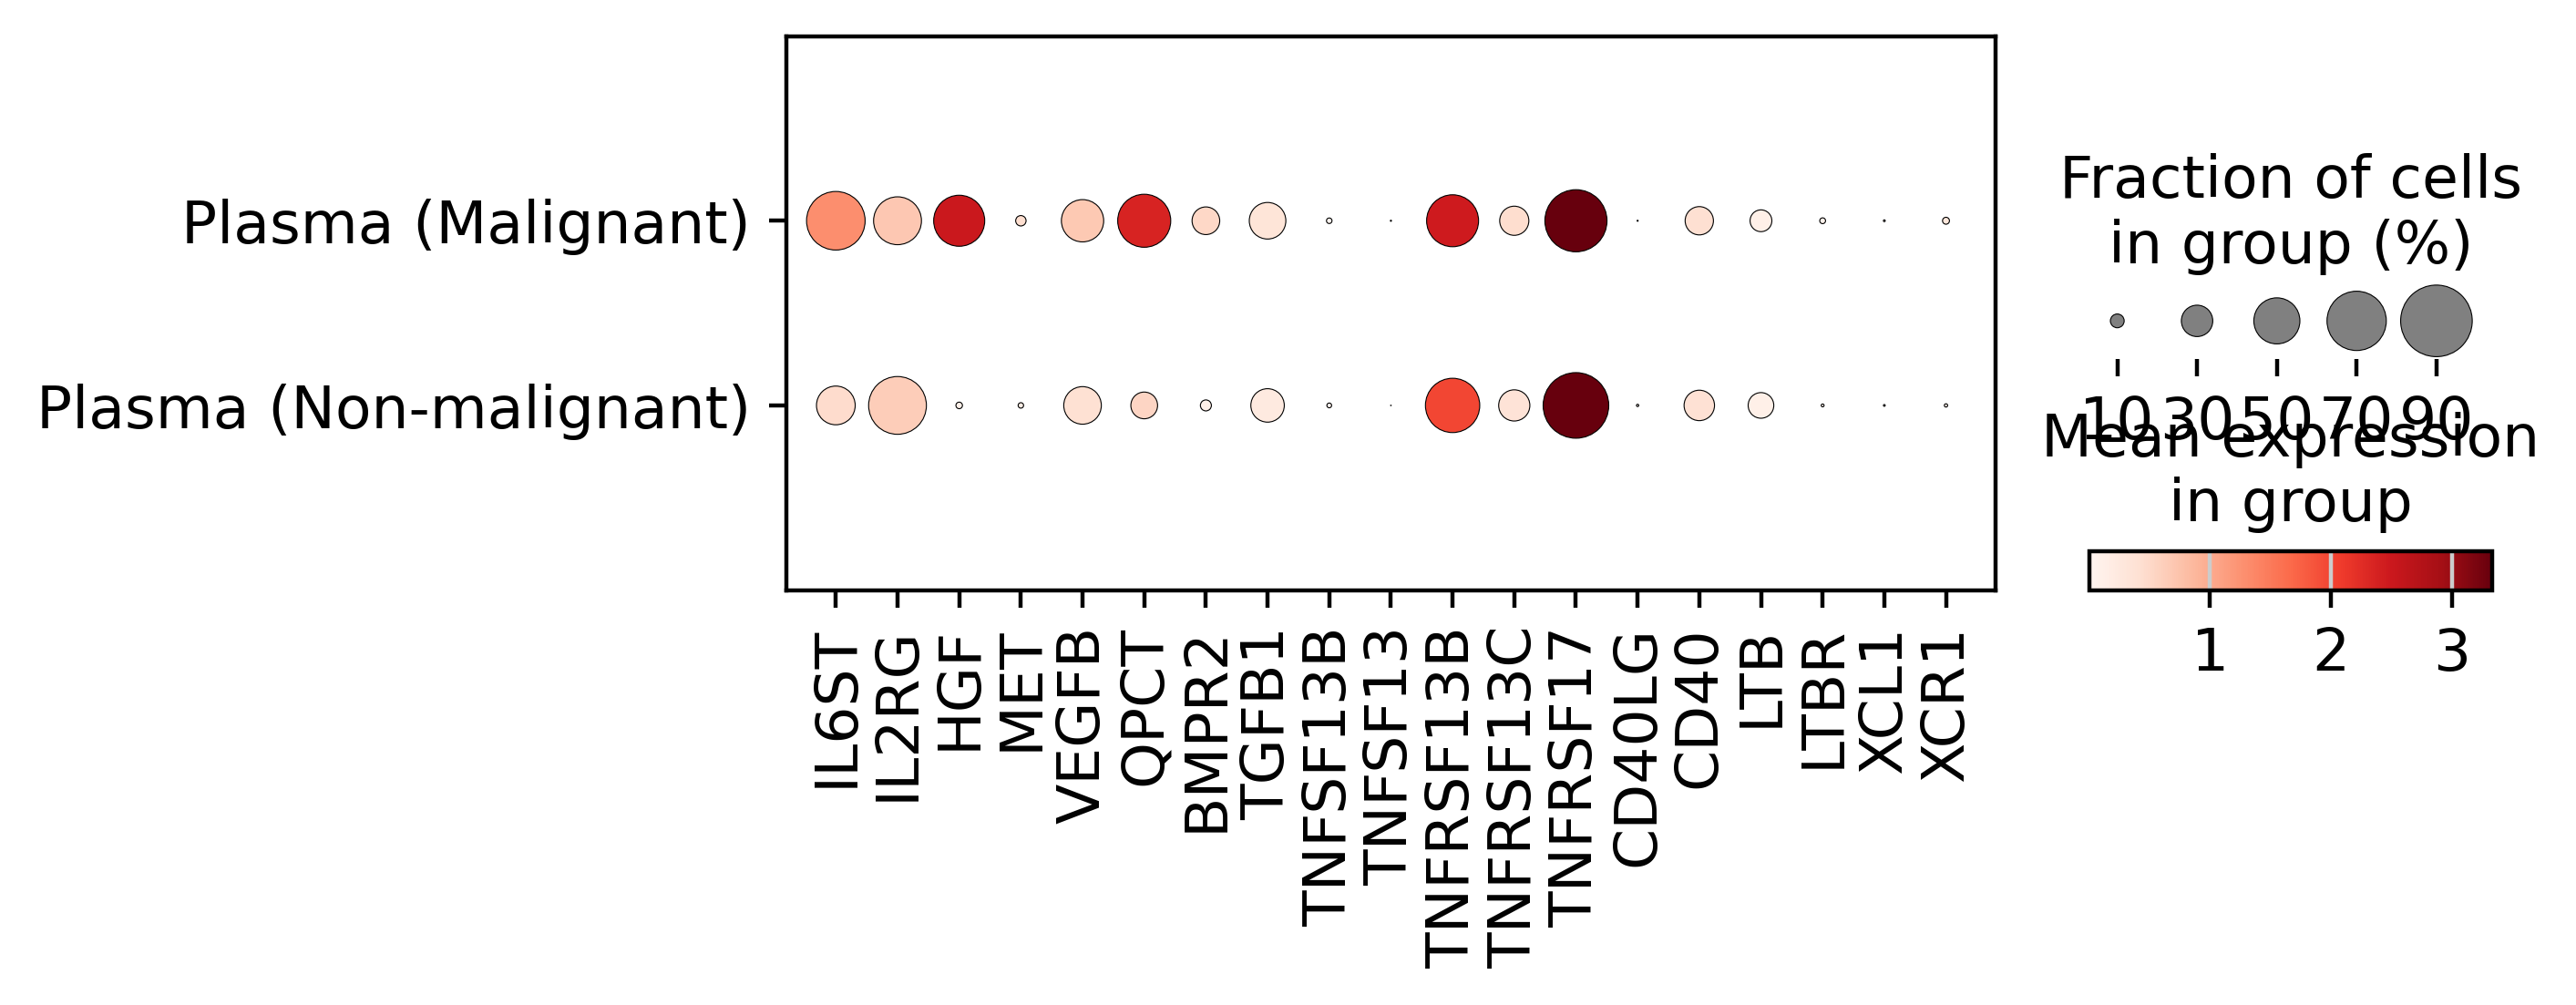

In [6]:
plt.rcParams["pdf.fonttype"] = 42
sc.pl.dotplot(
    adata_sub,
    var_names=genes,
    groupby="group",
    use_raw=False,
    dendrogram=False,
    swap_axes=False,
    show=False,
    figsize=(6, 2),
)
plt.savefig("../../data/figure-outputs/figure-2/fig_2f.pdf", dpi=200, bbox_inches="tight")